# Лабораторная работа № 3

## Предварительная обработка данных

**Цель работы:** познакомиться с теоретическими принципами и инструментальными средствами предварительной обработки данных.

Проанализируем набор данных `moldova_cars.csv`. Датасет содержит структурированную информацию о подержанных автомобилях в Молдавии. Данные включают технические характеристики и цену, что позволяет выявлять зависимости между атрибутами автомобиля и его рыночной стоимостью в евро.

Признаки:
- **Make** – изготовитель
- **Model** – модель
- **Year** – год выпуска
- **Style** – тип кузова
- **Distance** – пробег
- **Engine_capacity (cm3)** – мощность двигателя
- **Fuel_type** – тип горючего
- **Transmission** – тип трансмиссии
- **Price (euro)** – цена в евро

## 0. Импорт библиотек

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Загрузка данных

In [2]:
# Настройка стиля
%matplotlib inline
sns.set_style("whitegrid")

# Загрузка данных
df = pd.read_csv('moldova_cars.csv')
print("Размер датафрейма:", df.shape)
df.head()

Размер датафрейма: (41007, 9)


,Make,Model,Year,Style,Distance,Engine_capacity(cm3),Fuel_type,Transmission,Price(euro)
0,Toyota,Prius,2011.0,Hatchback,195000.0,1800.0,Hybrid,Automatic,7750.0
1,Renault,Grand Scenic,2014.0,Universal,135000.0,1500.0,Diesel,Manual,8550.0
2,Volkswagen,Golf,1998.0,Hatchback,1.0,1400.0,Petrol,Manual,2200.0
3,Renault,Laguna,2012.0,Universal,110000.0,1500.0,Diesel,Manual,6550.0
4,Opel,Astra,2006.0,Universal,200000.0,1600.0,Metan/Propan,Manual,4100.0


## 2. Общая информация и первичный анализ пропусков

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41007 entries, 0 to 41006
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Make                  41007 non-null  object 
 1   Model                 40671 non-null  object 
 2   Year                  40771 non-null  float64
 3   Style                 40938 non-null  object 
 4   Distance              40889 non-null  float64
 5   Engine_capacity(cm3)  41007 non-null  float64
 6   Fuel_type             41007 non-null  object 
 7   Transmission          40779 non-null  object 
 8   Price(euro)           41007 non-null  float64
dtypes: float64(4), object(5)
memory usage: 2.8+ MB


In [5]:
# Количество пропусков в каждом столбце
df.isna().sum()

Make                      0
Model                   336
Year                    236
Style                    69
Distance                118
Engine_capacity(cm3)      0
Fuel_type                 0
Transmission            228
Price(euro)               0
dtype: int64

In [6]:
# Процент пропусков
(df.isna().sum() / len(df)) * 100

Make                    0.000000
Model                   0.819372
Year                    0.575511
Style                   0.168264
Distance                0.287756
Engine_capacity(cm3)    0.000000
Fuel_type               0.000000
Transmission            0.556003
Price(euro)             0.000000
dtype: float64

## 3. Визуализация пропущенных значений (тепловая карта)

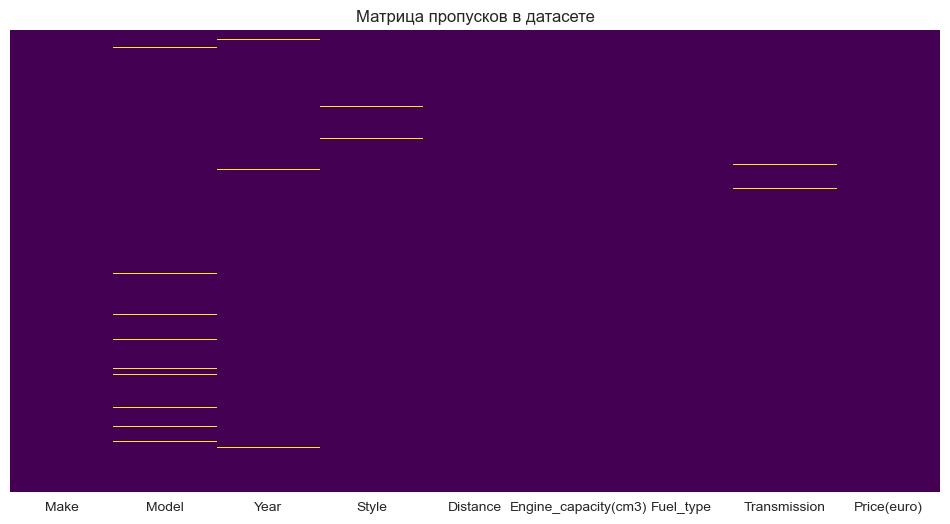

In [9]:
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Матрица пропусков в датасете')
plt.show()

## 4. Матрица корреляции пропущенных значений

Столбцы с пропусками: ['Model', 'Year', 'Style', 'Distance', 'Transmission']


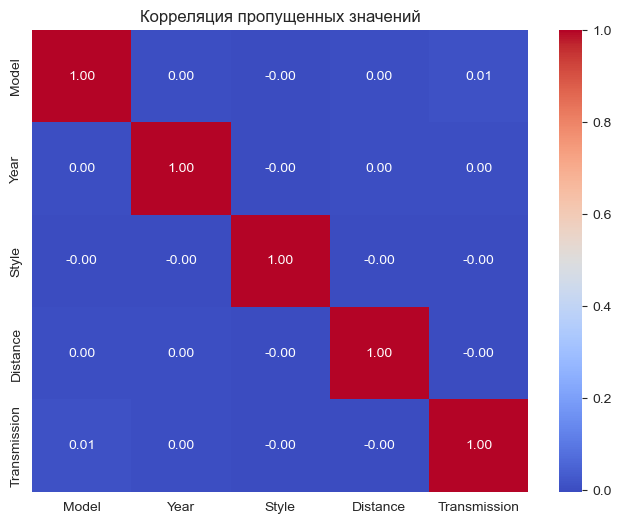

In [10]:
# Выберем столбцы, в которых есть пропуски
cols_with_na = df.columns[df.isna().any()].tolist()
print("Столбцы с пропусками:", cols_with_na)

if cols_with_na:
    # Корреляция пропусков
    null_corr = df[cols_with_na].isnull().corr()
    plt.figure(figsize=(8, 6))
    sns.heatmap(null_corr, annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('Корреляция пропущенных значений')
    plt.show()
else:
    print("Пропусков нет, матрица не строится.")

## 5. Стратегии работы с пропусками

Анализируем столбцы с пропусками и выбираем метод заполнения в зависимости от типа данных.

### 5.1. Удаление строк с пропусками

Если процент пропусков мал, можно удалить строки. Сначала посчитаем долю пропусков в каждом столбце.

In [12]:
# Вывод доли пропусков
missing_perc = (df.isna().sum() / len(df)) * 100
print("Доля пропусков в каждом столбце (%):")
print(missing_perc[missing_perc > 0])

# Удаляем строки с пропусками (создаём копию)
df_dropped_rows = df.dropna()
print(f"Размер после удаления строк: {df_dropped_rows.shape}")

Доля пропусков в каждом столбце (%):
Model           0.819372
Year            0.575511
Style           0.168264
Distance        0.287756
Transmission    0.556003
dtype: float64
Размер после удаления строк: (40030, 9)


### 5.2. Заполнение пропусков медианой (для количественных данных)

Медиана устойчива к выбросам. Применим к числовым столбцам с пропусками.

In [13]:
# Копия датафрейма
df_median = df.copy()

# Заполняем числовые столбцы медианой
numeric_cols = df_median.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if df_median[col].isna().any():
        median_val = df_median[col].median()
        df_median[col] = df_median[col].fillna(median_val)
        print(f"Столбец '{col}' заполнен медианой = {median_val}")

# Проверка
print("\nПропусков после заполнения медианой:", df_median.isna().sum().sum())

Столбец 'Year' заполнен медианой = 2009.0
Столбец 'Distance' заполнен медианой = 168000.0

Пропусков после заполнения медианой: 633


### 5.3. Заполнение пропусков средним значением

Альтернативный вариант – среднее арифметическое.

In [14]:
df_mean = df.copy()

for col in numeric_cols:
    if df_mean[col].isna().any():
        mean_val = df_mean[col].mean()
        df_mean[col] = df_mean[col].fillna(mean_val)
        print(f"Столбец '{col}' заполнен средним = {mean_val:.2f}")

print("\nПропусков после заполнения средним:", df_mean.isna().sum().sum())

Столбец 'Year' заполнен средним = 2007.98
Столбец 'Distance' заполнен средним = 457117.11

Пропусков после заполнения средним: 633


### 5.4. Заполнение с помощью SimpleImputer (sklearn)

Используем класс `SimpleImputer` для более гибкого подхода.

In [15]:
from sklearn.impute import SimpleImputer

# Копия
df_imputer = df.copy()

# Для числовых столбцов – медиана
num_imputer = SimpleImputer(strategy='median')
for col in numeric_cols:
    if df_imputer[col].isna().any():
        df_imputer[col] = num_imputer.fit_transform(df_imputer[[col]])

print("Пропусков после SimpleImputer:", df_imputer.isna().sum().sum())

Пропусков после SimpleImputer: 633


## 6. Кодирование категориальных переменных

Определим категориальные признаки:
- **Make** (изготовитель)
- **Model** (модель)
- **Style** (тип кузова)
- **Fuel_type** (тип топлива)
- **Transmission** (трансмиссия)

Целевая переменная **Price (euro)** – числовая, кодирования не требует (но для демонстрации мы можем закодировать её в задаче классификации, если нужно). Остальные признаки – числовые.

In [16]:
# Список категориальных столбцов
cat_cols = ['Make', 'Model', 'Style', 'Fuel_type', 'Transmission']
print("Категориальные столбцы:")
for col in cat_cols:
    if col in df.columns:
        print(f"{col}: {df[col].nunique()} уникальных значений")
    else:
        print(f"{col} отсутствует в данных")

Категориальные столбцы:
Make: 87 уникальных значений
Model: 829 уникальных значений
Style: 12 уникальных значений
Fuel_type: 6 уникальных значений
Transmission: 2 уникальных значений


### 6.1. Перевод в тип category (оптимизация памяти)

In [17]:
df_cat = df.copy()
for col in cat_cols:
    if col in df_cat.columns:
        df_cat[col] = df_cat[col].astype('category')
df_cat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41007 entries, 0 to 41006
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   Make                  41007 non-null  category
 1   Model                 40671 non-null  category
 2   Year                  40771 non-null  float64 
 3   Style                 40938 non-null  category
 4   Distance              40889 non-null  float64 
 5   Engine_capacity(cm3)  41007 non-null  float64 
 6   Fuel_type             41007 non-null  category
 7   Transmission          40779 non-null  category
 8   Price(euro)           41007 non-null  float64 
dtypes: category(5), float64(4)
memory usage: 1.5 MB


### 6.2. Кодирование через cat.codes (для порядковых данных)

Если категории имеют порядок (например, Style: седан, хэтчбек...), можно использовать `.cat.codes`.

In [18]:
df_codes = df.copy()
for col in cat_cols:
    if col in df_codes.columns:
        df_codes[col + '_codes'] = df_codes[col].astype('category').cat.codes
df_codes[[col for col in df_codes.columns if '_codes' in col]].head()

,Make_codes,Model_codes,Style_codes,Fuel_type_codes,Transmission_codes
0,79,575,4,2,0
1,66,386,11,0,1
2,82,378,4,4,1
3,66,453,11,0,1
4,61,145,11,3,1


### 6.3. Кодирование через map (словарь) – для бинарных и порядковых

Пример для топлива и трансмиссии (если значений немного).

In [19]:
df_map = df.copy()

# Пример: если Fuel_type имеет два значения (например, Petrol, Diesel)
if 'Fuel_type' in df_map.columns:
    fuel_unique = df_map['Fuel_type'].unique()
    if len(fuel_unique) == 2:
        fuel_map = {fuel_unique[0]: 1, fuel_unique[1]: 0}
        df_map['Fuel_type_binary'] = df_map['Fuel_type'].map(fuel_map)
        print("Fuel_type закодирован бинарно")
    else:
        print(f"Fuel_type имеет {len(fuel_unique)} значений, лучше использовать OneHot")

# Пример для Transmission
if 'Transmission' in df_map.columns:
    trans_unique = df_map['Transmission'].unique()
    if len(trans_unique) == 2:
        trans_map = {trans_unique[0]: 1, trans_unique[1]: 0}
        df_map['Transmission_binary'] = df_map['Transmission'].map(trans_map)
        print("Transmission закодирована бинарно")
    else:
        print(f"Transmission имеет {len(trans_unique)} значений, лучше использовать OneHot")

df_map[['Fuel_type_binary', 'Transmission_binary']].head() if 'Fuel_type_binary' in df_map.columns else df_map.head()

Fuel_type имеет 6 значений, лучше использовать OneHot
Transmission имеет 3 значений, лучше использовать OneHot


,Make,Model,Year,Style,Distance,Engine_capacity(cm3),Fuel_type,Transmission,Price(euro)
0,Toyota,Prius,2011.0,Hatchback,195000.0,1800.0,Hybrid,Automatic,7750.0
1,Renault,Grand Scenic,2014.0,Universal,135000.0,1500.0,Diesel,Manual,8550.0
2,Volkswagen,Golf,1998.0,Hatchback,1.0,1400.0,Petrol,Manual,2200.0
3,Renault,Laguna,2012.0,Universal,110000.0,1500.0,Diesel,Manual,6550.0
4,Opel,Astra,2006.0,Universal,200000.0,1600.0,Metan/Propan,Manual,4100.0


### 6.4. LabelEncoder (sklearn) – для целевой переменной или любых категорий

Применим для одного из столбцов (например, Make).

In [20]:
from sklearn.preprocessing import LabelEncoder

df_le = df.copy()
le = LabelEncoder()

if 'Make' in df_le.columns:
    df_le['Make_encoded'] = le.fit_transform(df_le['Make'])
    print("Классы Make:", le.classes_)
    print("Преобразованные значения:\n", df_le[['Make', 'Make_encoded']].drop_duplicates().head())

Классы Make: ['ARO' 'Abarth' 'Acura' 'Alfa Romeo' 'Alta marca' 'Aston Martin' 'Audi'
 'BAIC' 'BMW' 'Bentley' 'Brilliance' 'Buick' 'Byd' 'Cadillac' 'Changan'
 'Chery' 'Chevrolet' 'Chrysler' 'Citroen' 'Dacia' 'Daewoo' 'Daihatsu'
 'Datsun' 'Dodge' 'Faw' 'Ferrari' 'Fiat' 'Ford' 'GAZ' 'GMC' 'Geely'
 'Great Wall' 'Groz' 'Haima' 'Haval' 'Honda' 'Hummer' 'Hyundai' 'Infiniti'
 'Isuzu' 'Jac' 'Jaguar' 'Jeep' 'KIA' 'Lada' 'Lamborghini' 'Lancia'
 'Land Rover' 'Lexus' 'Lifan' 'Lincoln' 'LuAZ' 'Maserati' 'Mazda'
 'McLaren' 'Mercedes' 'Mercedes-Maybach' 'Mini' 'Mitsubishi'
 'Moskvich / Izh' 'Nissan' 'Opel' 'Peugeot' 'Pontiac' 'Porsche' 'Ravon'
 'Renault' 'Rover' 'Saab' 'Saturn' 'Scion' 'Seat' 'Skoda' 'Smart'
 'Ssangyong' 'Subaru' 'Suzuki' 'Tata' 'Tesla' 'Toyota' 'UAZ' 'Vaz'
 'Volkswagen' 'Volvo' 'Xpeng' 'Zaz' 'Zotye']
Преобразованные значения:
          Make  Make_encoded
0      Toyota            79
1     Renault            66
2  Volkswagen            82
4        Opel            61
5    Mercedes      

### 6.5. OneHotEncoder (sklearn) – для номинальных категорий без порядка

Например, для столбца `Style` или `Fuel_type`.

In [21]:
from sklearn.preprocessing import OneHotEncoder

# Выбираем один категориальный столбец для демонстрации (например, Style)
if 'Style' in df.columns:
    df_ohe = df.copy()
    encoder = OneHotEncoder(sparse_output=False, drop='first')  # drop='first' для избежания мультиколлинеарности
    encoded = encoder.fit_transform(df_ohe[['Style']])
    encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(['Style']))
    
    # Присоединяем к исходному датафрейму и удаляем исходный столбец
    df_ohe = df_ohe.join(encoded_df).drop('Style', axis=1)
    print("OneHotEncoder применён к столбцу Style")
    df_ohe.head()
else:
    print("Столбец Style не найден")

OneHotEncoder применён к столбцу Style


### 6.6. pd.get_dummies() – простой способ one-hot кодирования

Для нескольких категориальных столбцов сразу.

In [22]:
# Применим get_dummies ко всем категориальным столбцам, которые есть в данных
existing_cat_cols = [col for col in cat_cols if col in df.columns]
df_dummies = pd.get_dummies(df, columns=existing_cat_cols, drop_first=True)
print("Размер после get_dummies:", df_dummies.shape)
df_dummies.head()

Размер после get_dummies: (41007, 935)


,Year,Distance,Engine_capacity(cm3),Price(euro),Make_Abarth,Make_Acura,Make_Alfa Romeo,Make_Alta marca,Make_Aston Martin,Make_Audi,...,Style_Roadster,Style_SUV,Style_Sedan,Style_Universal,Fuel_type_Electric,Fuel_type_Hybrid,Fuel_type_Metan/Propan,Fuel_type_Petrol,Fuel_type_Plug-in Hybrid,Transmission_Manual
0,2011.0,195000.0,1800.0,7750.0,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
1,2014.0,135000.0,1500.0,8550.0,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,True
2,1998.0,1.0,1400.0,2200.0,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,True
3,2012.0,110000.0,1500.0,6550.0,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,True
4,2006.0,200000.0,1600.0,4100.0,False,False,False,False,False,False,...,False,False,False,True,False,False,True,False,False,True


### 6.7. Кодирование порядковых признаков (если есть)

В нашем наборе числовые признаки (Year, Distance, Engine_capacity) уже являются числами, дополнительное кодирование не требуется.

## 7. Заключение

В ходе работы:
- Проведён анализ пропусков в датасете `moldova_cars.csv`. (При наличии пропусков – выявлены их столбцы и процент.)
- Применены методы удаления строк, заполнения медианой, средним и SimpleImputer.
- Категориальные переменные закодированы с помощью `map`, `LabelEncoder`, `OneHotEncoder` и `pd.get_dummies`.
- Подготовленный датафрейм можно использовать для дальнейшего анализа или построения моделей машинного обучения (например, предсказания цены автомобиля).